In [8]:
import pandas as pd

df = pd.read_csv('../data/cpdb_master_with_classification.csv')

In [9]:


# So we only have the text features and the classification

# Need to create the text features column first

df['text_features'] = (
    df['policy_name'].fillna('') + " " + 
    df['policy_instrument'].fillna('') + " " + 
    df['policy_description'].fillna('')
)

df = df[['text_features', 'classification']]
print(df.head())

                                       text_features        classification
0  Intended Nationally Determined Contribution - ...  Neutral/Unclassified
1  Second Economic Development and Poverty Reduct...  Neutral/Unclassified
2  Law No. 16 of 22 May 2012, determining the Org...    Likely Progressive
3  Green Growth and Climate Resilience National S...    Likely Progressive
4  Kigali Amendment on HFCs Rwanda (2017) Target,...  Neutral/Unclassified


In [10]:
#When creating a classifier we need to split our data into 
#training and test sets
#we train on a portion of the data and test on another portion of the data
#important that these samples are performed randomly 
train = df.sample(frac = 0.8)
test = df.drop(train.index)
print(train.shape)
print(test.shape)

(586, 2)
(147, 2)


In [12]:
#sklearn is a very large library
#therefore we typically import only the functions we are actually going to use
from sklearn.feature_extraction.text import CountVectorizer

#A 'vectorizer' turns text data into a numeric matrix
#which can then be used by the model
vectorizer = CountVectorizer()
train_vectors = vectorizer.fit_transform(train['text_features'])
test_vectors = vectorizer.transform(test['text_features'])
#nb diff between transform and fit transform

In [13]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier()
clf.fit(train_vectors, train['classification'])
test['pred'] = clf.predict(test_vectors)

In [14]:
test.head()

,text_features,classification,pred
2,"Law No. 16 of 22 May 2012, determining the Org...",Likely Progressive,Neutral/Unclassified
4,"Kigali Amendment on HFCs Rwanda (2017) Target,...",Neutral/Unclassified,Neutral/Unclassified
11,Offshore Wind Energy Act (Amendment) - Increas...,Likely Progressive,Likely Progressive
13,Federal Climate Adaptation Act Germany (2024) ...,Neutral/Unclassified,Neutral/Unclassified
22,Ladesäulenverordnung (LSV) Germany (2016) Barr...,Likely Regressive,Neutral/Unclassified


In [15]:
#definitions can be found here: 
#https://medium.com/@shrutisaxena0617/precision-vs-recall-386cf9f89488
from sklearn import metrics
print(metrics.accuracy_score(test['classification'], test['pred']))
print(metrics.precision_score(test['classification'], test['pred'], average='macro'))
print(metrics.recall_score(test['classification'], test['pred'], average='macro'))

0.6190476190476191
0.5987211221122113
0.5277022718883184


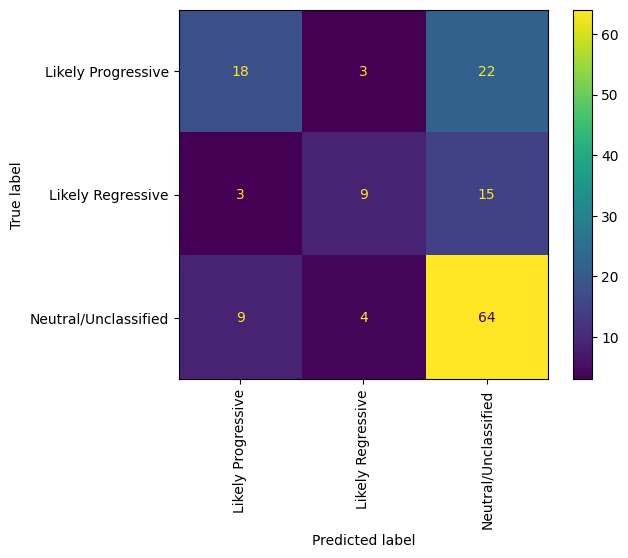

In [17]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test['classification'], test['pred'], labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=clf.classes_)
disp.plot(xticks_rotation = 'vertical')
plt.show()